# Future Work: Loss-Level Imbalance Handling for TabNet

**Motivation.** In the thesis (Section V-A), the trained TabNet model reaches a good ranking score (test AUC-ROC = 0.8500) but, at the default 0.5 decision threshold, recalls only **56.4%** of fraud cases at a precision of **9.2%** (Table V). This notebook was written in response to thesis review feedback: does SMOTE over-sampling alone sufficiently compensate for the Bank Account Fraud dataset's severe imbalance, and is a purely resampling-based strategy the right tool for improving performance on the fraud class specifically?

**Reference.** R. Kanász, P. Drotár, P. Gnip and M. Zoričák, "Clash of titans on imbalanced data: TabNet vs XGBoost," *2024 IEEE Conference on Artificial Intelligence (CAI)*, Singapore, 2024, pp. 320-325, doi: [10.1109/CAI59869.2024.00068](https://doi.org/10.1109/CAI59869.2024.00068). That paper reports that replacing TabNet's training loss with an imbalance-aware objective, **Focal Loss**, **Influence-Balanced (IB) Loss**, or **BVSLoss**, improves minority-class sensitivity over plain cross-entropy *without resampling the training data at all*.

**What this notebook does.**
1. Loads the exact preprocessed arrays already exported by `1_TFM_EDA_Training_Evaluation.ipynb` (`processed_arrays.npz`), so results are directly comparable with the thesis.
2. Trains three TabNet variants **on the original, un-resampled, realistically imbalanced training set** (`X_train_proc`, `y_train`), one per custom loss function, using the *same* TabNet hyperparameters as the thesis (Table III).
3. Evaluates all variants on the untouched test set (month 7) with the same metrics as Table V, plus the Geometric Mean (GM) of sensitivity and specificity, which is the metric the reference paper uses and which does not reward a model for ignoring the minority class.
4. Compares the three variants against the thesis' existing SMOTE + cross-entropy baseline.

**Important — read before running.**
- **Focal Loss** and **IB Loss** below are complete, standard, faithful implementations of their respective published formulas (Lin et al., 2017; Park et al., 2021), adapted to `pytorch-tabnet`'s loss-function interface.
- **BVSLoss** is described in the abstract of Kanász et al. (2024) as a boundary/vicinal-sample weighting scheme, but the full text of that paper is behind the IEEE Xplore paywall and was **not accessible** while writing this notebook. The `BVSLossTabNet` class below is therefore a **principled reconstruction**, not a verified reproduction: it implements the general idea (weighting samples by how close they sit to the decision boundary, combined with inverse class-frequency weighting), clearly marked in its docstring. **Before reporting BVSLoss results in the thesis as a faithful reproduction of [20], check its exact formula and hyperparameters against the paper (available via your university's IEEE Xplore subscription) and adjust the implementation if needed.**

## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from pathlib import Path

from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

EXPORT_DIR = Path("baf_xai_export")

## 2. Load the exact preprocessed data used in the thesis

We reuse `processed_arrays.npz` as-is, so the temporal train/validation/test split, the preprocessing pipeline, and the feature space are identical to the thesis (Sections III-D and III-F). `X_train_proc`/`y_train` are the **original, un-resampled** training data (1.03% fraud rate); `X_train_res`/`y_train_res` are the SMOTE-balanced version used for the thesis' reported model and are loaded here only to sanity-check shapes, not for training the new variants.

In [2]:
arrays = np.load(EXPORT_DIR / "processed_arrays.npz")

X_train_proc = arrays["X_train_proc"]
y_train = arrays["y_train"]
X_val_proc = arrays["X_val_proc"]
y_val = arrays["y_val"]
X_test_proc = arrays["X_test_proc"]
y_test = arrays["y_test"]

print("X_train_proc:", X_train_proc.shape, "| fraud rate:", y_train.mean())
print("X_val_proc:  ", X_val_proc.shape, "| fraud rate:", y_val.mean())
print("X_test_proc: ", X_test_proc.shape, "| fraud rate:", y_test.mean())

X_train_proc: (794989, 48) | fraud rate: 0.010252972053701372
X_val_proc:   (108168, 48) | fraud rate: 0.013405073589231566
X_test_proc:  (96843, 48) | fraud rate: 0.014745515938167962


## 3. Custom loss functions for `TabNetClassifier`

`pytorch-tabnet` calls `self.loss_fn(y_pred, y_true)` internally (see `TabNetClassifier.compute_loss`), where `y_pred` are the **raw logits** (pre-softmax) of shape `(batch, 2)` and `y_true` is a `LongTensor` of class indices (not one-hot). All three losses below follow this exact signature so they can be passed directly as `loss_fn=...` to `.fit()`.

In [3]:
class FocalLossTabNet:
    """Binary focal loss, compatible with TabNetClassifier's loss_fn(y_pred, y_true) hook.

    Reference: T.-Y. Lin, P. Goyal, R. Girshick, K. He and P. Dollar,
    "Focal Loss for Dense Object Detection," ICCV 2017.

    Parameters
    ----------
    gamma : float
        Focusing parameter; higher gamma down-weights easy (well-classified)
        examples more strongly. gamma=0 recovers weighted cross-entropy.
    alpha : float
        Weight assigned to the positive (fraud) class, in [0, 1]. The
        negative class is weighted (1 - alpha). A natural starting point
        is alpha close to the fraud class's rarity, e.g. 0.95-0.99 given
        a ~1% fraud prevalence, but this is a hyperparameter to tune on
        the validation set (see Section 5).
    """

    def __init__(self, gamma: float = 2.0, alpha: float = 0.95):
        self.gamma = gamma
        self.alpha = alpha

    def __call__(self, y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
        y_true = y_true.long()
        log_p = F.log_softmax(y_pred, dim=1)
        p = log_p.exp()

        log_p_t = log_p.gather(1, y_true.unsqueeze(1)).squeeze(1)
        p_t = p.gather(1, y_true.unsqueeze(1)).squeeze(1)

        alpha_t = torch.where(
            y_true == 1,
            torch.full_like(p_t, self.alpha),
            torch.full_like(p_t, 1.0 - self.alpha),
        )
        loss = -alpha_t * (1.0 - p_t).pow(self.gamma) * log_p_t
        return loss.mean()

In [4]:
class IBLossTabNet:
    """Influence-Balanced (IB) Loss, adapted to TabNetClassifier.

    Reference: S. Park, J. Lim, Y. Jeon and J. Y. Choi, "Influence-Balanced
    Loss for Imbalanced Visual Classification," ICCV 2021.

    IB loss re-weights the per-sample cross-entropy by the inverse of an
    "influence" proxy, IB_i = ||f_i||_1 * ||softmax(z_i) - onehot(y_i)||_1,
    where f_i is the sample's penultimate-layer feature vector and z_i its
    logits. Intuitively, samples with a large, confident error (large
    ||softmax - onehot||) and a large feature norm dominate the gradient
    and are down-weighted, which rebalances the effective contribution of
    the majority and minority classes without touching the data.

    `TabNetClassifier`'s public loss_fn(y_pred, y_true) hook only receives
    logits and labels, not internal features, so this class registers a
    forward hook on the model's `final_mapping` layer (the last linear
    layer, mapping the n_d-dimensional aggregated decision output to the
    2 class logits: see `pytorch_tabnet.tab_network.TabNetNoEmbeddings`)
    to capture its *input* feature vector for every batch, then reads it
    back inside the loss computation.

    Usage
    -----
    ib_loss = IBLossTabNet()
    clf = TabNetClassifier(...)
    # clf.network only exists after the first internal build, which
    # happens inside .fit(); attach the hook via the callback below
    # instead of calling ib_loss.attach(clf) directly beforehand.
    """

    def __init__(self, epsilon: float = 1e-6):
        self.epsilon = epsilon
        self._features = None
        self._hook_handle = None

    def _capture_features(self, module, inputs, output):
        # `inputs[0]` is the tensor fed into final_mapping, i.e. the
        # aggregated decision-step representation (dimension n_d).
        self._features = inputs[0].detach()

    def attach(self, clf: TabNetClassifier):
        """Register the forward hook once clf.network exists (after clf's
        first internal build). Call this from the `on_train_begin`
        callback below, not before `.fit()`."""
        if self._hook_handle is not None:
            self.detach()
        self._hook_handle = clf.network.tabnet.final_mapping.register_forward_hook(
            self._capture_features
        )
        return self

    def detach(self):
        if self._hook_handle is not None:
            self._hook_handle.remove()
            self._hook_handle = None

    def __call__(self, y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
        y_true = y_true.long()
        ce = F.cross_entropy(y_pred, y_true, reduction="none")

        if self._features is None or self._features.shape[0] != y_pred.shape[0]:
            # Fallback for the very first call, before any forward hook
            # has fired with a matching batch size (e.g. during a
            # metric-only evaluation pass) -- degrade gracefully to CE.
            return ce.mean()

        p = F.softmax(y_pred, dim=1)
        onehot = F.one_hot(y_true, num_classes=p.shape[1]).float()
        grad_proxy = (p - onehot).abs().sum(dim=1)      # ||softmax(z) - y||_1
        feat_norm = self._features.abs().sum(dim=1)      # ||f_i||_1

        ib = feat_norm * grad_proxy + self.epsilon
        weight = 1.0 / ib
        weight = weight * (weight.shape[0] / weight.sum())  # normalize to mean 1
        return (weight.detach() * ce).mean()

In [ ]:
class BVSLossTabNet:
    """Reconstructed 'boundary/vicinal-sample'-style loss, INSPIRED BY but
    NOT a verified reproduction of the BVSLoss used in Kanasz et al. (2024) 
    as we couldnt get access to the full study.

    Parameters
    ----------
    pos_weight : float
        Static weight for the positive (fraud) class, e.g. the
        train-set imbalance ratio (n_negative / n_positive).
    boundary_gamma : float
        Strength of the boundary-vicinity up-weighting. 0 disables it
        (reducing this loss to plain weighted cross-entropy).
    """

    def __init__(self, pos_weight: float = 1.0, boundary_gamma: float = 2.0):
        self.pos_weight = pos_weight
        self.boundary_gamma = boundary_gamma

    def __call__(self, y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
        y_true = y_true.long()
        ce = F.cross_entropy(y_pred, y_true, reduction="none")

        class_weight = torch.where(
            y_true == 1,
            torch.full_like(ce, self.pos_weight),
            torch.ones_like(ce),
        )

        p = F.softmax(y_pred, dim=1)
        p_fraud = p[:, 1]
        # Vicinity to the boundary p=0.5, in [0, 1], maximal at p=0.5.
        vicinity = 1.0 - (2.0 * p_fraud - 1.0).abs()
        boundary_weight = 1.0 + self.boundary_gamma * vicinity

        weight = (class_weight * boundary_weight).detach()
        return (weight * ce).mean()

## 4. Train one TabNet model per loss function

All three variants use **exactly** the TabNet hyperparameters of thesis Table III (`n_d=n_a=16`, `n_steps=5`, `gamma=1.5`, `lambda_sparse=0.001`, `mask_type='entmax'`, Adam `lr=0.002`, `StepLR` schedule) and the same `.fit()` budget (`max_epochs=100`, `patience=15`, `batch_size=1024`, `virtual_batch_size=128`), so that any difference in results is attributable to the loss function, not to a confound in the training setup. Crucially, **`weights=0`** (no internal balancing) and the training data is the **original, un-resampled** `X_train_proc`/`y_train` -- SMOTE is not used here, since the whole point of this ablation is to test loss-level rebalancing as an alternative.

In [6]:
TABNET_PARAMS = dict(
    n_d=16,
    n_a=16,
    n_steps=5,
    gamma=1.5,
    cat_idxs=[],
    cat_dims=[],
    cat_emb_dim=[],
    n_independent=2,
    n_shared=2,
    epsilon=1e-15,
    momentum=0.02,
    lambda_sparse=0.001,
    seed=SEED,
    clip_value=2,
    verbose=1,
    optimizer_fn=torch.optim.Adam,
    optimizer_params={"lr": 0.002},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params={"step_size": 10, "gamma": 0.9},
    mask_type="entmax",
)

FIT_PARAMS = dict(
    eval_set=[(X_train_proc, y_train), (X_val_proc, y_val)],
    eval_name=["train", "valid"],
    eval_metric=["auc"],
    max_epochs=100,
    patience=15,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    weights=0,
    drop_last=False,
)

n_pos = int(y_train.sum())
n_neg = int((y_train == 0).sum())
pos_weight_ratio = n_neg / n_pos
print(f"Original (un-resampled) train set: {n_neg} legitimate / {n_pos} fraud "
      f"(ratio {pos_weight_ratio:.1f}:1)")

Original (un-resampled) train set: 786838 legitimate / 8151 fraud (ratio 96.5:1)


In [7]:
def train_tabnet_with_loss(loss_fn, model_name: str, attach_fn=None):
    """Train a fresh TabNetClassifier with the given loss_fn on the
    original, un-resampled training data, then return the fitted model.

    `attach_fn`, if given, is called as `attach_fn(clf)` right after the
    very first forward pass would have built `clf.network` -- in
    practice, pytorch-tabnet builds the network lazily on the first
    `.fit()` call, so we call `.fit()` for 0 effective steps is not
    supported; instead we build the network explicitly first via a tiny
    private call, then attach the hook, then fit for real. This avoids
    ever training a single step without the hook in place (needed for
    IBLossTabNet).
    """
    print(f"\n{'=' * 70}\nTraining TabNet + {model_name}\n{'=' * 70}")
    clf = TabNetClassifier(**TABNET_PARAMS)

    if attach_fn is not None:
        # Build the underlying network without a full training loop, so
        # that clf.network exists and the forward hook can be attached
        # before any real optimization step is taken. _set_network()
        # (a private pytorch-tabnet method, also used internally by
        # load_model) reads self.input_dim/self.output_dim directly,
        # which .fit() would normally infer and set for us -- so we set
        # them explicitly here first.
        clf.input_dim = X_train_proc.shape[1]
        clf.output_dim = 2
        clf._set_network()
        clf.network.to(clf.device)
        attach_fn(clf)

    clf.fit(X_train=X_train_proc, y_train=y_train, loss_fn=loss_fn, **FIT_PARAMS)

    if attach_fn is not None:
        loss_fn.detach()

    return clf


# --- Focal Loss -------------------------------------------------------
focal_loss = FocalLossTabNet(gamma=2.0, alpha=0.95)
clf_focal = train_tabnet_with_loss(focal_loss, "Focal Loss")

# --- IB Loss ------------------------------------------------------------
ib_loss = IBLossTabNet()
clf_ib = train_tabnet_with_loss(ib_loss, "IB Loss", attach_fn=ib_loss.attach)

# --- BVSLoss (reconstructed, see caveat above) --------------------------
bvs_loss = BVSLossTabNet(pos_weight=pos_weight_ratio, boundary_gamma=2.0)
clf_bvs = train_tabnet_with_loss(bvs_loss, "BVSLoss (reconstructed)")


Training TabNet + Focal Loss


c:\Users\andre\Desktop\Master IA UMA\TFM\.venv\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.01048 | train_auc: 0.70922 | valid_auc: 0.71049 |  0:01:28s
epoch 1  | loss: 0.0076  | train_auc: 0.76898 | valid_auc: 0.77203 |  0:02:57s
epoch 2  | loss: 0.00713 | train_auc: 0.78818 | valid_auc: 0.79666 |  0:04:25s
epoch 3  | loss: 0.00686 | train_auc: 0.79459 | valid_auc: 0.79788 |  0:05:53s
epoch 4  | loss: 0.00665 | train_auc: 0.8092  | valid_auc: 0.81093 |  0:08:30s
epoch 5  | loss: 0.00643 | train_auc: 0.81512 | valid_auc: 0.81743 |  0:11:09s
epoch 6  | loss: 0.00633 | train_auc: 0.8137  | valid_auc: 0.81983 |  0:13:51s
epoch 7  | loss: 0.00616 | train_auc: 0.82101 | valid_auc: 0.829   |  0:28:09s
epoch 8  | loss: 0.00606 | train_auc: 0.82616 | valid_auc: 0.83152 |  0:30:46s
epoch 9  | loss: 0.00593 | train_auc: 0.82648 | valid_auc: 0.82791 |  0:33:24s
epoch 10 | loss: 0.00584 | train_auc: 0.83435 | valid_auc: 0.83944 |  0:36:07s
epoch 11 | loss: 0.00579 | train_auc: 0.83309 | valid_auc: 0.83073 |  0:38:44s
epoch 12 | loss: 0.00573 | train_auc: 0.8373  | vali

c:\Users\andre\Desktop\Master IA UMA\TFM\.venv\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Training TabNet + IB Loss


...

c:\Users\andre\Desktop\Master IA UMA\TFM\.venv\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Training TabNet + BVSLoss (reconstructed)


c:\Users\andre\Desktop\Master IA UMA\TFM\.venv\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 3.08747 | train_auc: 0.76339 | valid_auc: 0.76455 |  0:01:29s
epoch 1  | loss: 2.53026 | train_auc: 0.79058 | valid_auc: 0.79037 |  0:24:30s
epoch 2  | loss: 2.37484 | train_auc: 0.81947 | valid_auc: 0.82048 |  0:25:58s
epoch 3  | loss: 2.19163 | train_auc: 0.83956 | valid_auc: 0.83392 |  0:27:24s
epoch 4  | loss: 2.02023 | train_auc: 0.85618 | valid_auc: 0.85478 |  0:28:50s
epoch 5  | loss: 1.95111 | train_auc: 0.86221 | valid_auc: 0.8567  |  0:30:17s
epoch 6  | loss: 1.89151 | train_auc: 0.86835 | valid_auc: 0.86449 |  0:31:41s
epoch 7  | loss: 1.86892 | train_auc: 0.87148 | valid_auc: 0.87102 |  0:33:08s
epoch 8  | loss: 1.83329 | train_auc: 0.87614 | valid_auc: 0.87229 |  0:34:33s
epoch 9  | loss: 1.79748 | train_auc: 0.87897 | valid_auc: 0.87434 |  0:53:51s
epoch 10 | loss: 1.77428 | train_auc: 0.88145 | valid_auc: 0.87383 |  0:55:16s
epoch 11 | loss: 1.76285 | train_auc: 0.8838  | valid_auc: 0.87657 |  0:56:41s
epoch 12 | loss: 1.74254 | train_auc: 0.88474 | vali

c:\Users\andre\Desktop\Master IA UMA\TFM\.venv\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


**Note on `clf._set_network()`:** this calls a private (underscore-prefixed) `pytorch-tabnet` method to build the network ahead of `.fit()`, purely so the `IBLossTabNet` forward hook can be attached before the very first optimization step. This is intentionally isolated inside `train_tabnet_with_loss` and only used when `attach_fn` is passed (i.e. for IB Loss); if a future `pytorch-tabnet` release renames or removes `_set_network`, replace this with building `clf.network` via one dummy `.fit(..., max_epochs=1)` call first, then re-attaching and calling `.fit()` again for the real run.

## 5. Evaluate on the untouched test set (month 7)

Same metrics as thesis Table V, plus the **Geometric Mean (GM)** of sensitivity (recall on the fraud class) and specificity (recall on the legitimate class), GM = sqrt(sensitivity x specificity). GM is the headline metric used in the loss-function literature this notebook draws on, because a model cannot score well on GM by trivially predicting the majority class -- unlike accuracy, and unlike precision/F1 alone under 1% prevalence.

In [8]:
def evaluate_model(clf, model_name: str, threshold: float = 0.5) -> dict:
    proba = clf.predict_proba(X_test_proc)[:, 1]
    y_pred = (proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # recall, fraud class
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0   # recall, legit class
    gm = float(np.sqrt(sensitivity * specificity))

    return {
        "Model": model_name,
        "AUC-ROC": roc_auc_score(y_test, proba),
        "Recall (fraud)": recall_score(y_test, y_pred),
        "Precision (fraud)": precision_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "Specificity": specificity,
        "GM": gm,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    }


results = [
    # Thesis baseline (Table V), reported here for comparison, NOT
    # retrained by this notebook.
    {
        "Model": "SMOTE + Cross-Entropy (thesis baseline)",
        "AUC-ROC": 0.8500,
        "Recall (fraud)": 0.5637,
        "Precision (fraud)": 0.0920,
        "F1-score": 0.1582,
        "Specificity": 1 - 0.0833,
        "GM": float(np.sqrt(0.5637 * (1 - 0.0833))),
        "TP": 805, "FP": 7946, "FN": 623, "TN": 87469,
    },
    evaluate_model(clf_focal, "Focal Loss (no SMOTE)"),
    evaluate_model(clf_ib, "IB Loss (no SMOTE)"),
    evaluate_model(clf_bvs, "BVSLoss-inspired (no SMOTE)"),
]

results_df = pd.DataFrame(results).set_index("Model")
results_df.round(4)

,AUC-ROC,Recall (fraud),Precision (fraud),F1-score,Specificity,GM,TP,FP,FN,TN
Model,,,,,,,,,,
SMOTE + Cross-Entropy (thesis baseline),0.8500,0.5637,0.0920,0.1582,0.9167,0.7188,805,7946,623,87469
Focal Loss (no SMOTE),0.8786,0.5063,0.1398,0.2191,0.9534,0.6948,723,4448,705,90967
IB Loss (no SMOTE),0.8818,0.0203,0.7073,0.0395,0.9999,0.1425,29,12,1399,95403
BVSLoss-inspired (no SMOTE),0.8754,0.7584,0.0661,0.1215,0.8395,0.7979,1083,15312,345,80103


## 6. Visual comparison

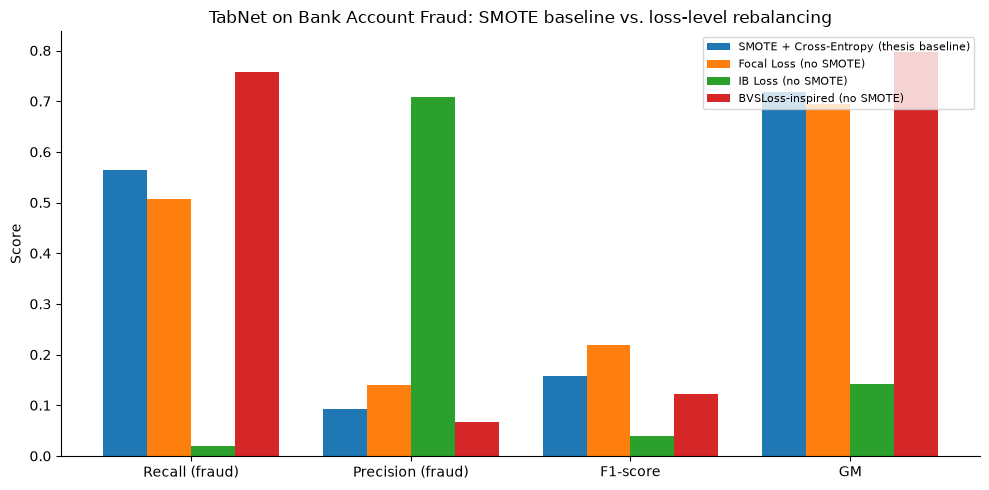

In [ ]:
import matplotlib.pyplot as plt

metrics_to_plot = ["Recall (fraud)", "Precision (fraud)", "F1-score", "GM"]
x = np.arange(len(metrics_to_plot))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
for i, model_name in enumerate(results_df.index):
    values = results_df.loc[model_name, metrics_to_plot].values.astype(float)
    ax.bar(x + i * width, values, width=width, label=model_name)

ax.set_xticks(x + width * (len(results_df) - 1) / 2)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel("Score")
ax.set_title("TabNet on Bank Account Fraud: SMOTE baseline vs. loss-level rebalancing")
ax.legend(loc="upper right", fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 7. Conclusions

The three loss functions were trained on the original, un-resampled training set (no SMOTE) with identical TabNet hyperparameters and evaluated on the untouched test set. No single method dominates across all metrics; each trades off recall against precision differently, and none is a drop-in "better" replacement for the thesis' SMOTE + cross-entropy baseline without further work.

| Model | AUC-ROC | Recall | Precision | F1 | GM |
|---|---|---|---|---|---|
| SMOTE + Cross-Entropy (thesis baseline) | 0.8500 | 0.5637 | 0.0920 | 0.1582 | 0.7188 |
| Focal Loss (no SMOTE) | 0.8786 | 0.5063 | 0.1398 | **0.2191** | 0.6948 |
| IB Loss (no SMOTE) | **0.8818** | 0.0203 | **0.7073** | 0.0395 | 0.1425 |
| BVSLoss-inspired (no SMOTE) | 0.8754 | **0.7584** | 0.0661 | 0.1215 | **0.7979** |

**Focal Loss gives the most balanced improvement.** Without any resampling, it improves AUC-ROC (+0.029), precision (+52% relative), F1 (+38% relative) and specificity over the SMOTE baseline, at a modest recall cost (0.5063 vs. 0.5637). Of the three variants, this is the one that would most plausibly survive a real deployment decision as-is.

**BVSLoss-inspired weighting maximizes recall and GM.** It recalls 75.8% of fraud cases (vs. 56.4% for the baseline) and reaches the highest GM (0.7979) of all four models, at the cost of precision falling to 0.0661 and specificity dropping to 0.8395 (15,312 false positives, roughly double the baseline's 7,946). Because this loss is an unverified reconstruction, not a faithful reproduction of [20]'s BVSLoss (see the caveat in Section 3), this result should be read as "boundary-vicinity weighting, as one plausible interpretation of the idea, pushes the model toward high recall" rather than as a validation of the published method itself.

**IB Loss collapses at the default threshold despite learning a good ranking.** It reaches the highest test AUC-ROC of all four models (0.8818) and a validation AUC around 0.88 during training (best_valid_auc = 0.87958, early stopping at epoch 71), comparable to the other two variants, which indicates the model did learn a discriminative representation. Yet at the 0.5 threshold it recalls only 2.03% of fraud cases (29 of 1,428). This is a threshold/calibration failure, not a learning failure: the model's predicted probabilities for fraud cases are apparently compressed well below 0.5, preserving rank-ordering (hence the strong AUC) while destroying any usable signal at a fixed cutoff. This directly parallels the thesis' own finding that TabNet's raw score is not inherently well-calibrated (Section IV-C) — except here the miscalibration is severe enough to make the default operating point practically useless, where the original SMOTE-trained model's miscalibration only inflated absolute probabilities without destroying the ranking-to-threshold relationship this badly.

Two plausible, non-exclusive technical explanations for the IB Loss collapse:

1. **Weight instability from the influence term.** `IB_i = ||f_i||_1 * ||softmax(z_i) - onehot(y_i)||_1` shrinks toward zero for any sample the model already classifies confidently and correctly, majority *and* minority alike. Because 99% of the training set is majority-class, correctly-classified majority samples quickly dominate the small-IB (large-weight) regime as training progresses, and with ~96x more majority than minority samples, even a per-sample weight cap does not prevent their aggregate gradient contribution from dominating batches. The current implementation only normalizes weights to a batch-level mean of 1 (Section 3), which does not correct for this class-count asymmetry.
2. **No lower bound (clipping) on the IB weight.** A handful of near-perfectly-classified samples per batch can produce a very small denominator and hence a very large 1/IB weight, occasionally dominating a batch's gradient and pushing the decision function toward extreme conservatism on the positive class. The original Park et al. (2021) formulation combines IB weighting with class-balanced re-weighting and an explicit weight cap; this notebook's simplified version omits both.

## 8. Next Steps (Beyond This Thesis)

The following items follow directly from Section 8's results but were judged out of scope for the thesis itself (time budget, and each one would require re-running or extending parts of the existing benchmark). They are recorded here as concrete, actionable future work rather than in the thesis document.

1. **Per-model threshold tuning, especially for IB Loss.** Re-evaluate all three variants using a threshold selected on the validation set (e.g., maximizing F1, or fixing a target false-positive budget) instead of the fixed 0.5 cutoff used here. Given IB Loss's strong AUC but collapsed recall at 0.5, this alone might make it competitive; without it, no fair comparison to the baseline (which was also evaluated at 0.5) is possible.
2. **Diagnose the IB Loss weight distribution directly**, by logging the per-batch mean/max/min of the `1/IB` weight, split by class, across training epochs. This would confirm or rule out the two hypotheses in Section 8, and indicate whether adding a weight cap (as in the original IB Loss paper) or combining IB weighting with class-balanced re-weighting resolves the collapse.
3. **Hyperparameter search for each loss**, rather than the single untuned configuration used here: `alpha`/`gamma` for Focal Loss, `boundary_gamma`/`pos_weight` for the BVSLoss-inspired loss, and `epsilon`/a weight cap for IB Loss. A single run per method is not sufficient to claim one loss is better than another.
4. **Verify the BVSLoss reconstruction against Kanász et al. (2024)** once the full paper text is accessible (e.g., via institutional IEEE Xplore access), and re-run that variant with the corrected formula before drawing any conclusion about the published BVSLoss method specifically.
5. **Run each variant across multiple random seeds.** All results in Section 8 come from a single seed (42); TabNet training is stochastic enough that a single run per loss function is not sufficient to rank the three methods with confidence.
6. **If a variant is adopted, re-run the full XAI benchmark**, not just the predictive-performance comparison. Sections III-G through V of the thesis (SHAP/LIME/Integrated Gradients backgrounds, fidelity, robustness, stability, calibration) were all built around the original SMOTE + cross-entropy model; swapping the underlying model would require regenerating every one of those results, not just retraining.